In [1]:
# import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load Dataset
df = pd.read_csv('ai_dev_productivity.csv')

In [3]:
df.shape

(500, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hours_coding      500 non-null    float64
 1   coffee_intake_mg  500 non-null    int64  
 2   distractions      500 non-null    int64  
 3   sleep_hours       500 non-null    float64
 4   commits           500 non-null    int64  
 5   bugs_reported     500 non-null    int64  
 6   ai_usage_hours    500 non-null    float64
 7   cognitive_load    500 non-null    float64
 8   task_success      500 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
df.describe()

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,5.015600,463.192000,2.976000,6.975800,4.60800,0.858000,1.510920,4.498200,0.606000
std,1.947253,142.334991,1.678409,1.455965,2.70499,1.102846,1.085557,1.868861,0.489124
min,0.000000,6.000000,0.000000,3.000000,0.00000,0.000000,0.000000,1.000000,0.000000
25%,3.600000,369.500000,2.000000,6.100000,3.00000,0.000000,0.697500,3.175000,0.000000
50%,5.030000,500.500000,3.000000,6.950000,5.00000,0.000000,1.260000,4.400000,1.000000
75%,6.275000,600.000000,4.000000,7.900000,6.00000,2.000000,2.070000,5.800000,1.000000
max,12.000000,600.000000,8.000000,10.000000,13.00000,5.000000,6.360000,10.000000,1.000000


In [31]:
# Checking missing values
df.isnull().sum()

,0
hours_coding,0
coffee_intake_mg,0
distractions,0
sleep_hours,0
commits,0
bugs_reported,0
ai_usage_hours,0
cognitive_load,0
task_success,0


In [32]:
# Checking duplicate values
df.duplicated().sum()

np.int64(0)

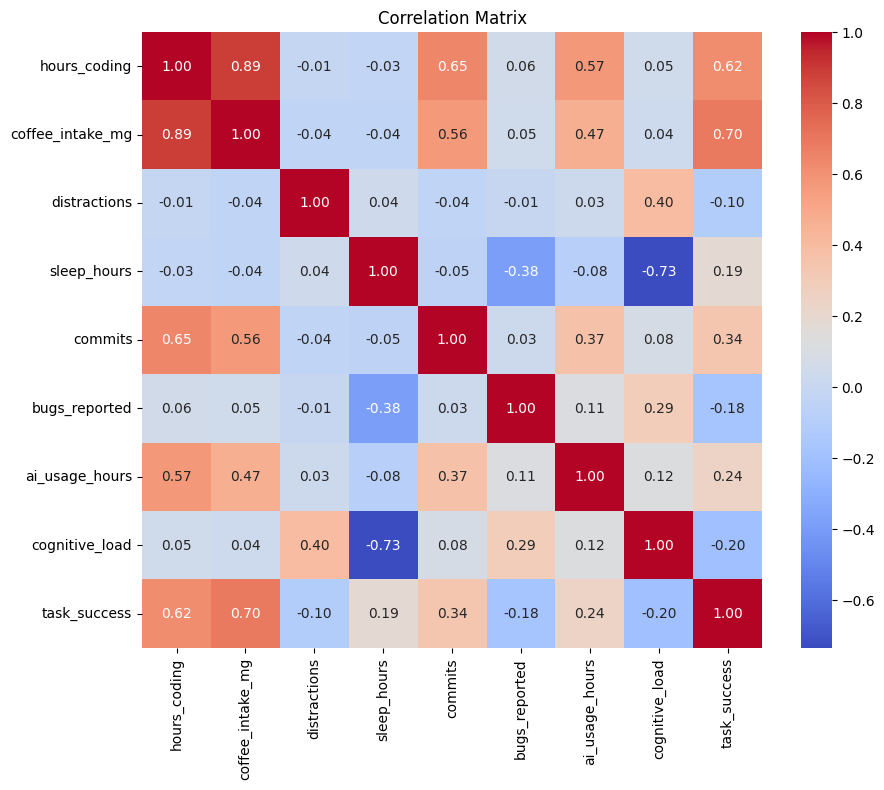

In [8]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

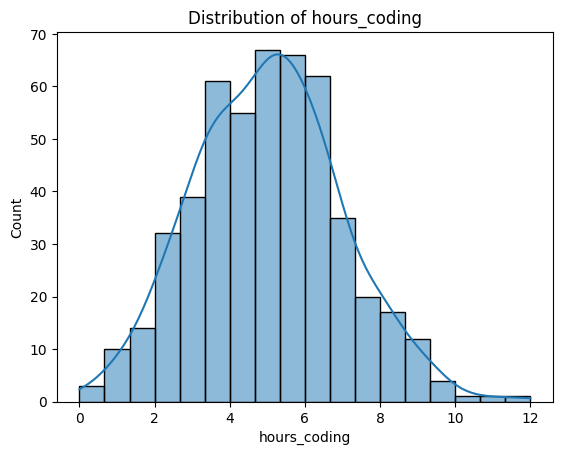

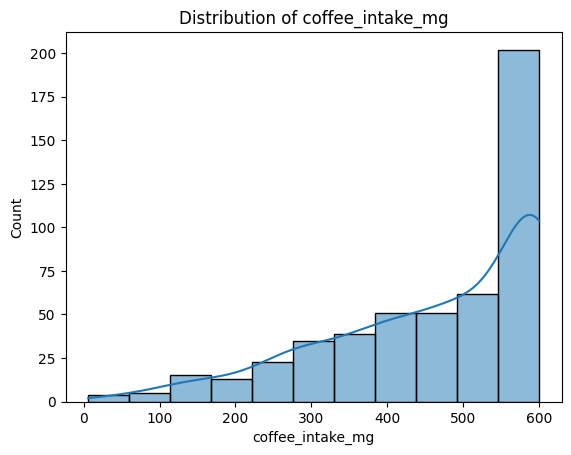

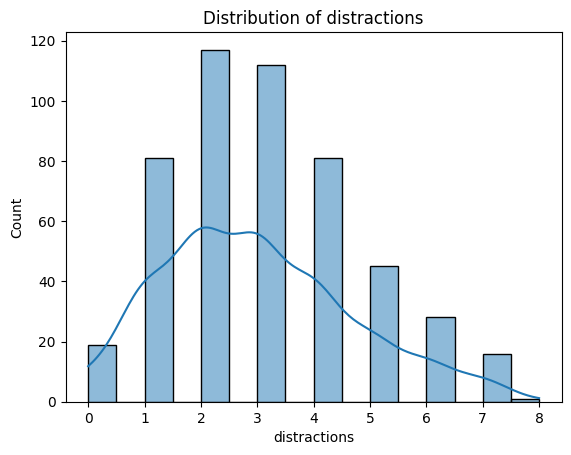

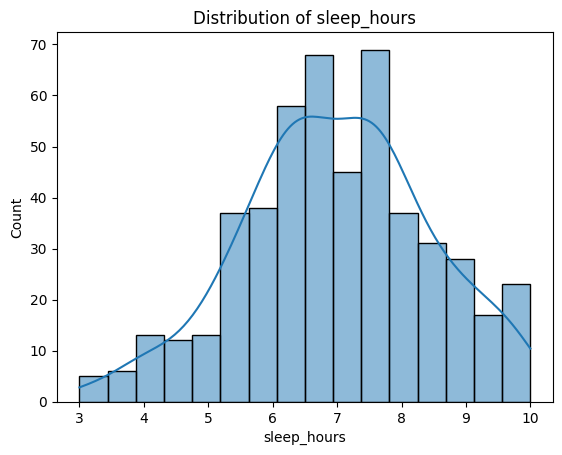

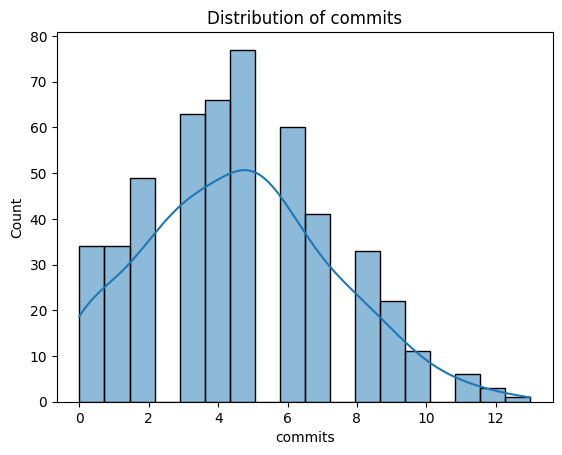

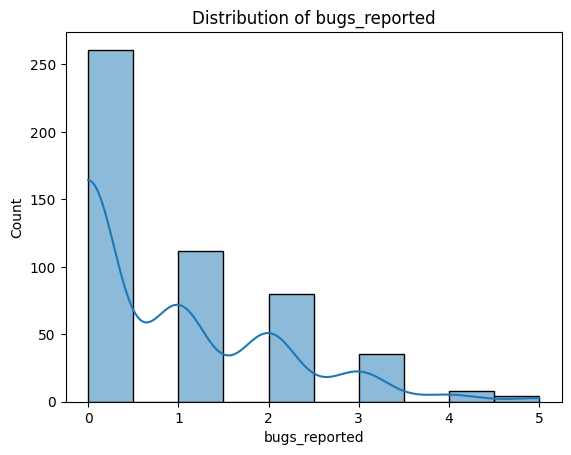

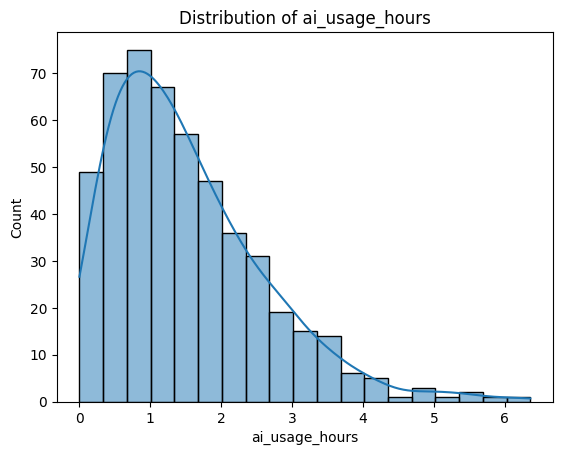

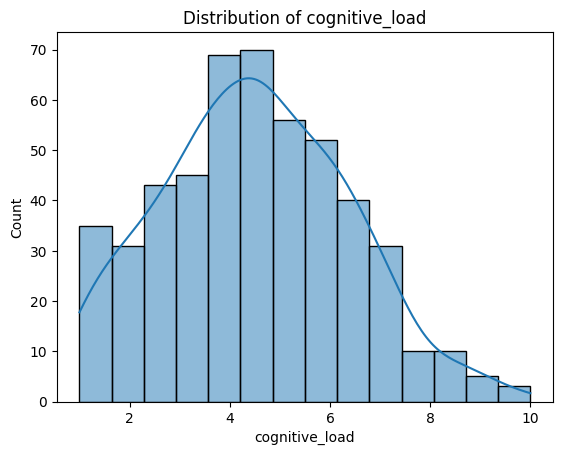

In [9]:
# Histograms
target_column = 'task_success'

for col in df.select_dtypes(include="number").columns:
    if col != target_column:
        sns.histplot(data=df, x=col, kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()

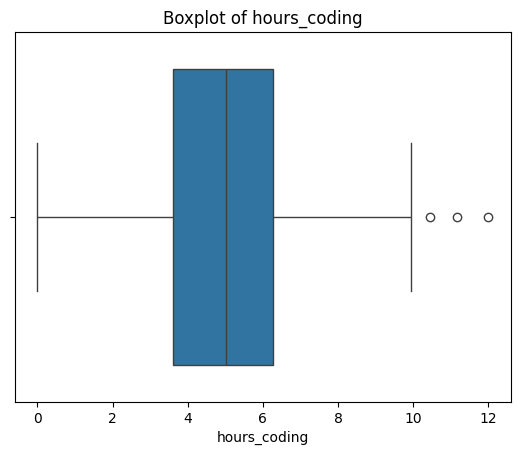

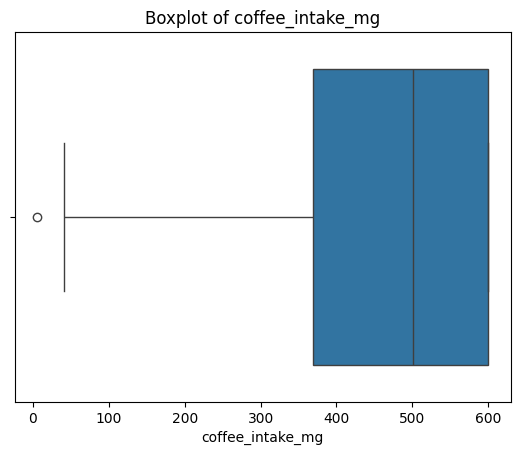

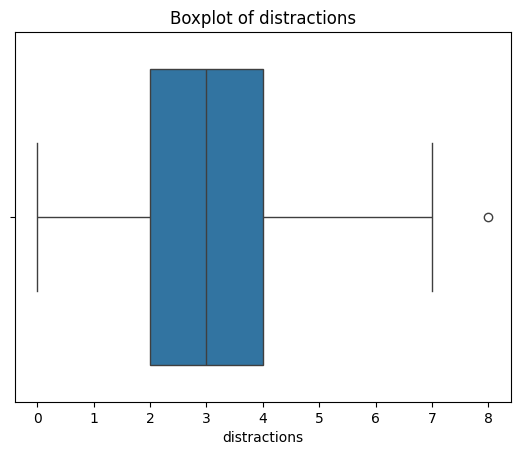

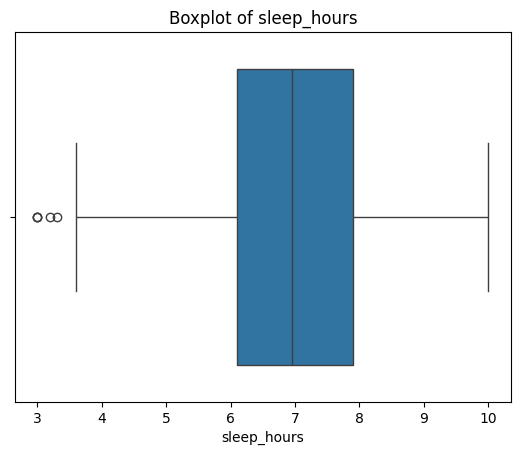

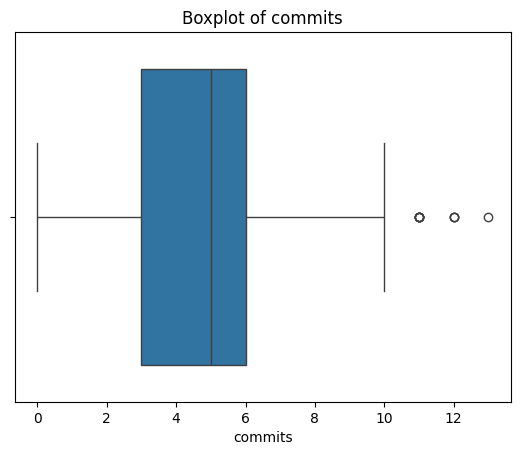

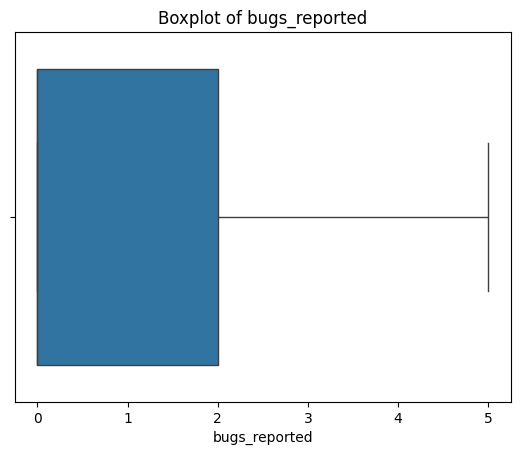

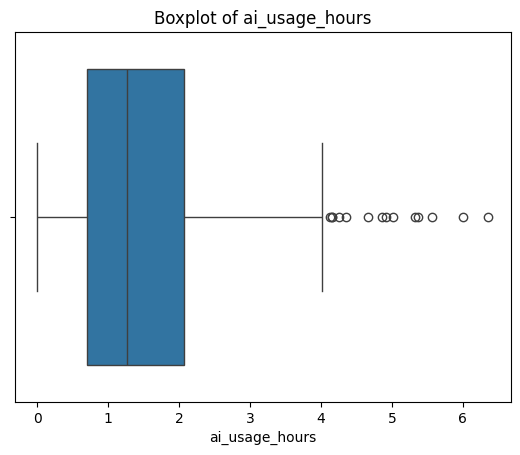

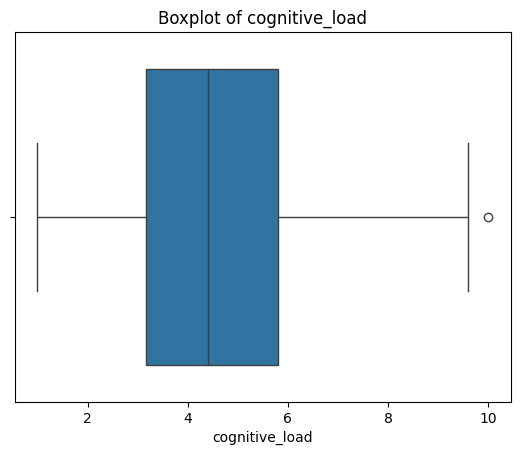

In [10]:
# Boxplots for outliers visualization
for col in df.select_dtypes(include="number").columns:
    if col != target_column:
        sns.boxplot(data=df, x=col)
        plt.title(f'Boxplot of {col}')
        plt.show()

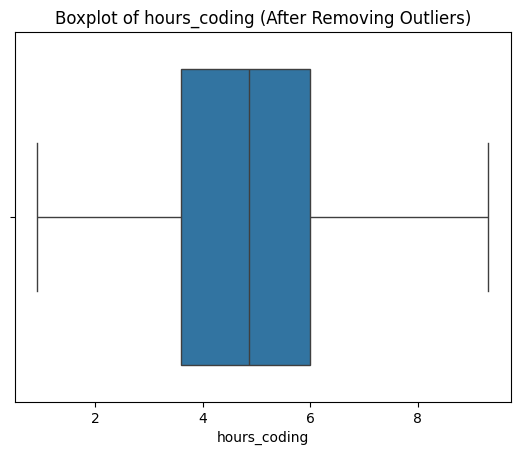

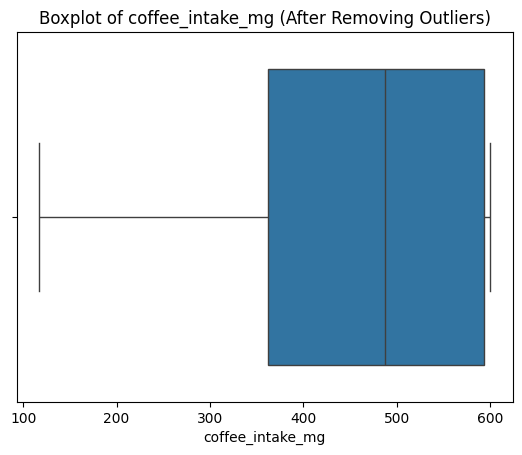

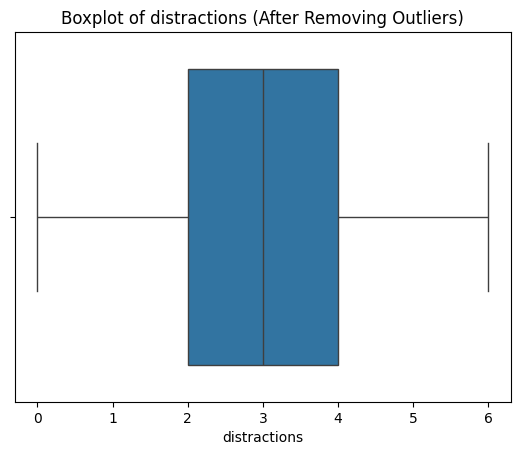

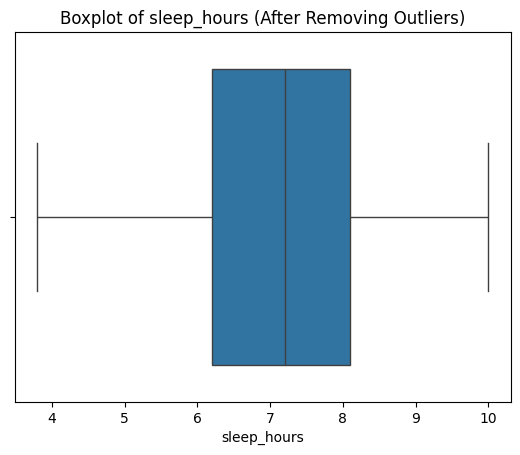

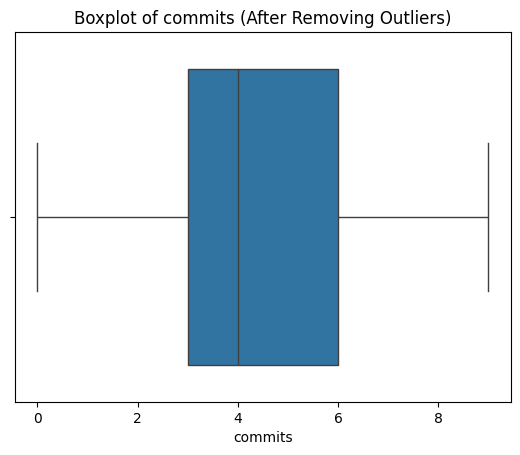

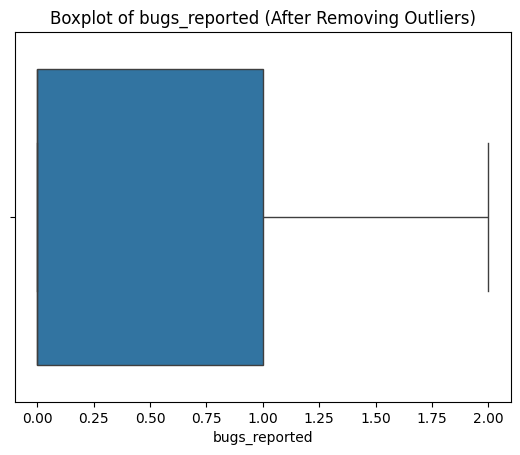

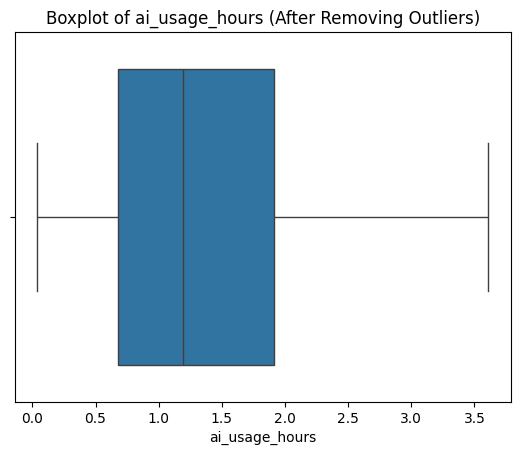

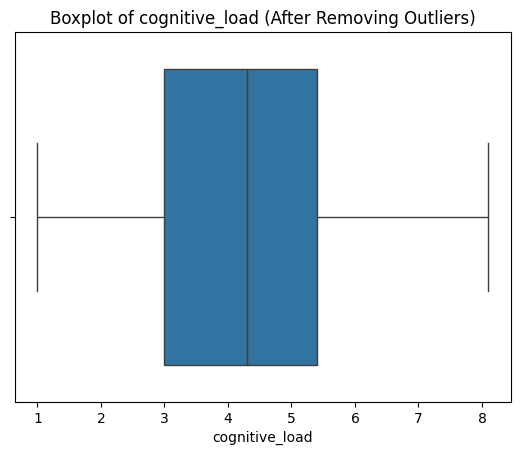

In [11]:
# Remove Outliers using IQR method
def remove_outliers_iqr(df, columns):
    df_filtered = df.copy()
    for col in columns:
        Q1 = df_filtered[col].quantile(0.25)
        Q3 = df_filtered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.2 * IQR
        upper_bound = Q3 + 1.2 * IQR
        df_filtered = df_filtered[(df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound)]
    return df_filtered

numeric_cols = df.select_dtypes(include='number').columns
df_no_outliers = remove_outliers_iqr(df, numeric_cols)

# Boxplots After Cleaning Outliers
for col in df_no_outliers.select_dtypes(include="number").columns:
    if col != target_column:
        sns.boxplot(data=df_no_outliers, x=col)
        plt.title(f'Boxplot of {col} (After Removing Outliers)')
        plt.show()


In [19]:
# Feature and Target Split
X = df_no_outliers.drop('task_success', axis=1)
y = df_no_outliers['task_success']

In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Standar Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.9230769230769231


In [24]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Confusion Matrix:
 [[23  3]
 [ 3 49]]


In [25]:
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        26
           1       0.94      0.94      0.94        52

    accuracy                           0.92        78
   macro avg       0.91      0.91      0.91        78
weighted avg       0.92      0.92      0.92        78



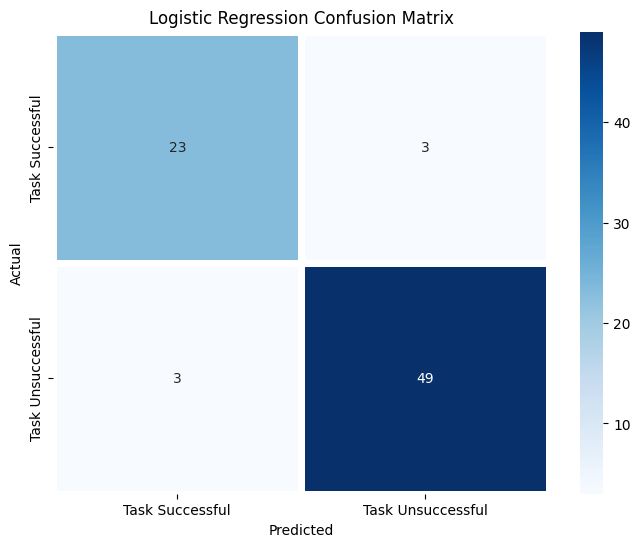

In [33]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d", linewidth=5, cmap="Blues",
            xticklabels=["Task Successful", "Task Unsuccessful"],
            yticklabels=["Task Successful", "Task Unsuccessful"])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
# Actual vs Predicted Logistic
comparison_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_log})
print("\nComparison (First 10 rows):\n", comparison_df.head(10))



Comparison (First 10 rows):
    Actual  Predicted
0       1          0
1       1          0
2       1          1
3       0          0
4       0          0
5       0          0
6       1          1
7       1          1
8       1          1
9       1          1


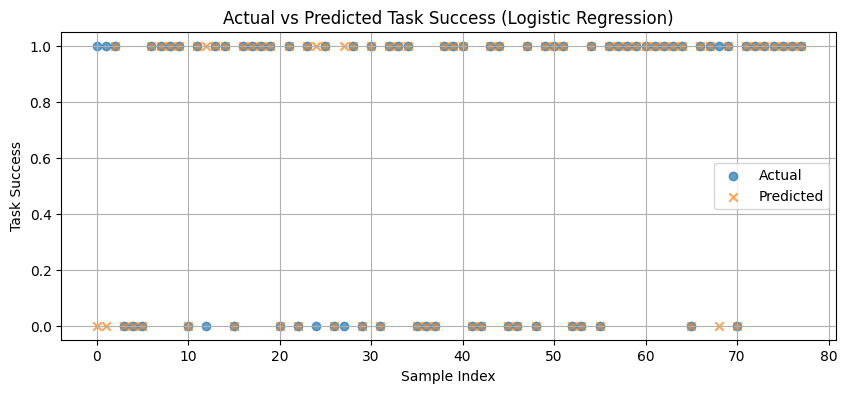

In [28]:
# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(10, 4))
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.7)
plt.scatter(range(len(y_pred_log)), y_pred_log, label='Predicted', marker='x', alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Task Success (Logistic Regression)")
plt.xlabel("Sample Index")
plt.ylabel("Task Success")
plt.grid(True)
plt.show()

In [29]:
# Save the Trained Pipeline (after training and testing)
from sklearn.pipeline import Pipeline
import joblib

# Combine scaler and model into one pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('classifier', log_model)
])

# Save the model pipeline
joblib.dump(pipeline, 'ai_task_success_model.pkl')
print("Model pipeline saved successfully!")


Model pipeline saved successfully!


In [30]:
# Load trained model pipeline
model = joblib.load('ai_task_success_model.pkl')

# Ask user for inputs
input_data = {
    'hours_coding': float(input("Enter total focused hours spent on software development work (0–12 hours): ")),
    'coffee_intake_mg': int(input("Enter daily caffeine intake in milligrams (0–600 mg)")),
    'distractions': int(input("Enter number of distractions (e.g., meetings, Slack notifications) (0–10) ")),
    'sleep_hours': float(input("Enter number of hours of sleep the previous night (3–10 hours) ")),
    'commits': int(input("Enter number of code commits pushed during the day (0–20) ")),
    'bugs_reported': int(input("Enter number of bugs reported in code written that day (0–10) ")),
    'ai_usage_hours': float(input("Enter number of hours spent using AI tools (e.g., ChatGPT, Copilot) (0–12) ")),
    'cognitive_load': float(input("Enter self-reported mental strain on a scale of 1 to 10: "))
}

# Convert to DataFrame
input_df = pd.DataFrame([input_data])

# Make prediction
prediction = model.predict(input_df)
prediction_proba = model.predict_proba(input_df)
print()

# Print result
if prediction[0] == 1:
    print("The model predicts the developer WILL successfully complete the task.")
else:
    print("The model predicts the developer will NOT successfully complete the task.")

print(f"Probability of task success: {prediction_proba[0][1]:.2f}")

Enter total focused hours spent on software development work (0–12 hours): 6
Enter daily caffeine intake in milligrams (0–600 mg)300
Enter number of distractions (e.g., meetings, Slack notifications) (0–10) 6
Enter number of hours of sleep the previous night (3–10 hours) 5
Enter number of code commits pushed during the day (0–20) 7
Enter number of bugs reported in code written that day (0–10) 5
Enter number of hours spent using AI tools (e.g., ChatGPT, Copilot) (0–12) 8
Enter self-reported mental strain on a scale of 1 to 10: 5

The model predicts the developer will NOT successfully complete the task.
Probability of task success: 0.23
